<a href="https://colab.research.google.com/github/Elsacred02/Progetto_AML_2025_2026/blob/main/Codice_progetto_AML_2025_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import librerie

import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import hashlib
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers
from google.colab import drive
from tensorflow.keras.applications.efficientnet import preprocess_input
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Monta dataset da google drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/sea_animals"
# os.listdir(DATA_DIR)

Mounted at /content/drive


In [3]:
# Script per verificare se ci sono immagini duplicate tra le cartelle

# Funzione per calcolare hash MD5 di un file
def hash_file(file_path):
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

# Dizionario per raccogliere hash
hashes = defaultdict(list)

# Esplorazione delle directory
for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            file_hash = hash_file(file_path)
            hashes[file_hash].append(file_path)
        except Exception as e:
            print(f"Errore leggendo {file_path}: {e}")

# Stampa dei duplicati
print("Duplicati trovati:")
for file_list in hashes.values():
    if len(file_list) > 1:
        print(" - " + "\n   ".join(file_list))
        print()


Duplicati trovati:
 - /content/drive/MyDrive/Colab Notebooks/sea_animals/Sea Urchins/2410254965_997a170847_o.jpg
   /content/drive/MyDrive/Colab Notebooks/sea_animals/Sea Urchins/2415324362_7af0d50dff_o.jpg

 - /content/drive/MyDrive/Colab Notebooks/sea_animals/Sea Urchins/3084448568_c73bd84762_o.jpg
   /content/drive/MyDrive/Colab Notebooks/sea_animals/Sea Urchins/2515696078_30911f8022_o.jpg

 - /content/drive/MyDrive/Colab Notebooks/sea_animals/Sea Urchins/14663143746_ab57259f86_o.jpg
   /content/drive/MyDrive/Colab Notebooks/sea_animals/Sea Urchins/9268307830_8cca53090c_o.jpg

 - /content/drive/MyDrive/Colab Notebooks/sea_animals/Clams/33573217048_49779c6e3a_o.jpg
   /content/drive/MyDrive/Colab Notebooks/sea_animals/Octopus/33573217048_49779c6e3a_o.jpg

 - /content/drive/MyDrive/Colab Notebooks/sea_animals/Clams/35267497856_25562bf235_o.jpg
   /content/drive/MyDrive/Colab Notebooks/sea_animals/Sea Rays/35267497856_25562bf235_o.jpg

 - /content/drive/MyDrive/Colab Notebooks/sea_anim

In [4]:
# Le immagini sono tutte di dimensione 300 x N o N x 300 con N valore variabile tra le immagini ed N < 300
# Troviamo N minimo e massimo per immagini orizzontali e verticali

dimensions = {
    "min_vertical" : -1,
    "min_horizontal" : -1,
    "max_vertical" : -1,
    "max_horizontal" : -1,
    "biggest_vertical" : None,
    "biggest_horizontal" : None,
    "removed_images" : 0
}

for directory in os.listdir(DATA_DIR):
    for image in os.listdir(os.path.join(DATA_DIR, directory)):
        img = tf.keras.preprocessing.image.load_img(os.path.join(DATA_DIR, directory, image))

        width, height = img.size

        if width > height:
            # L'immagine è orizzontale
            if height > 300:
                dimensions["removed_images"] += 1
                os.remove(os.path.join(DATA_DIR, directory, image))
            elif dimensions["min_horizontal"] == -1 or height < dimensions["min_horizontal"]:
                dimensions["min_horizontal"] = height
            elif dimensions["max_horizontal"] == -1 or height > dimensions["max_horizontal"]:
                dimensions["max_horizontal"] = height
                dimensions["biggest_horizontal"] = os.path.join(directory, image)
        else:
            # L'immagine è verticale
            if width > 300:
                dimensions["removed_images"] += 1
                os.remove(os.path.join(DATA_DIR, directory, image))
            elif dimensions["min_vertical"] == -1 or width < dimensions["min_vertical"]:
                dimensions["min_vertical"] = width
            elif dimensions["max_vertical"] == -1 or width > dimensions["max_vertical"]:
                dimensions["max_vertical"] = width
                dimensions["biggest_vertical"] = os.path.join(directory, image)

print(dimensions)

{'min_vertical': 131, 'min_horizontal': 63, 'max_vertical': 300, 'max_horizontal': 299, 'biggest_vertical': 'Sea Urchins/30905610620_bbfaf7a558_o.jpg', 'biggest_horizontal': 'Seahorse/5120505560_0617580092_o.jpg', 'removed_images': 0}


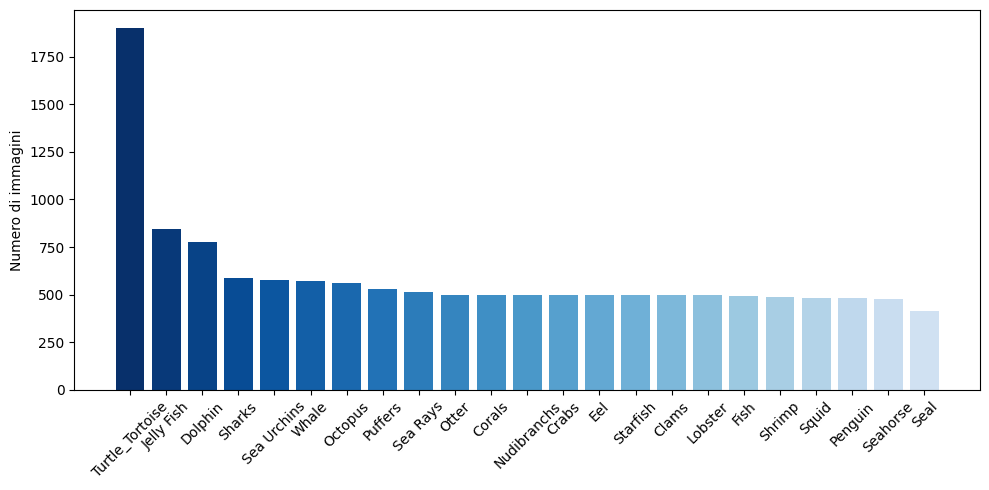

In [19]:
# Controllo bilanciamento dataset
# TBD : nella relazione la tabella andrà sotto la voce "Distribuzione immagini per classe"

dict_targets_NElements = {}

# Popola il dizionario con le coppie (target, numero di immagini)
for directory in os.listdir(DATA_DIR):
    dict_targets_NElements[directory] = len(os.listdir(os.path.join(DATA_DIR, directory)))

# Ordina il dizionario in modo decrescente
dict_targets_NElements = dict(sorted(dict_targets_NElements.items(), key=lambda x: x[1], reverse=True))

# Crea palette di colori sulla base del numero di elementi del dizionario
colors = plt.cm.Blues(np.linspace(1, 0.2, len(dict_targets_NElements)))

# Grafico della distribuzione immagini per classe
plt.figure(figsize=(10, 5))
plt.bar(dict_targets_NElements.keys(), dict_targets_NElements.values(), color=colors)
plt.xticks(rotation=45)
plt.ylabel("Numero di immagini")
plt.tight_layout()
plt.show()

In [20]:
num_classes = len(dict_targets_NElements)
print(f"Numero di classi: {num_classes}")

# Calcolo class weights per bilanciare il dataset
from sklearn.utils.class_weight import compute_class_weight

# Raccolgo tutte le etichette del training set
all_labels = []
class_names_ordered = sorted(dict_targets_NElements.keys())

for idx, class_name in enumerate(class_names_ordered):
    num_samples = dict_targets_NElements[class_name]
    all_labels.extend([idx] * num_samples)

# Calcolo i pesi usando la formula 'balanced': n_samples / (n_classes * n_samples_per_class)
class_weights_array = compute_class_weight(
    'balanced',
    classes=np.arange(num_classes),
    y=all_labels
)

# Converto in dizionario {indice_classe: peso}
class_weights = dict(enumerate(class_weights_array))

print("\nClass Weights calcolati:")
for class_idx, class_name in enumerate(class_names_ordered):
    print(f"  {class_name}: {class_weights[class_idx]:.4f}")

Numero di classi: 23

Class Weights calcolati:
  Clams: 1.1990
  Corals: 1.1918
  Crabs: 1.1942
  Dolphin: 0.7644
  Eel: 1.1966
  Fish: 1.2063
  Jelly Fish: 0.7046
  Lobster: 1.1990
  Nudibranchs: 1.1918
  Octopus: 1.0620
  Otter: 1.1894
  Penguin: 1.2364
  Puffers: 1.1221
  Sea Rays: 1.1525
  Sea Urchins: 1.0271
  Seahorse: 1.2441
  Seal: 1.4399
  Sharks: 1.0114
  Shrimp: 1.2262
  Squid: 1.2338
  Starfish: 1.1966
  Turtle_Tortoise: 0.3130
  Whale: 1.0452


In [21]:
# 80% train, 10% validation, 10% test
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split = 0.2,
    subset = "training",
    seed = 123,
    image_size = (224, 224),
    batch_size = 32
)

val_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split = 0.2,
    subset = "validation",
    seed = 123,
    image_size = (224, 224),
    batch_size = 32
)

# Calcolo il numero di batch e le uso per dividere la seconda porzione del dataset
val_test_batches = tf.data.experimental.cardinality(val_test_ds)
val_ds = val_test_ds.take((val_test_batches) // 2)
test_ds = val_test_ds.skip((val_test_batches) // 2)

Found 13678 files belonging to 23 classes.
Using 10943 files for training.
Found 13678 files belonging to 23 classes.
Using 2735 files for validation.


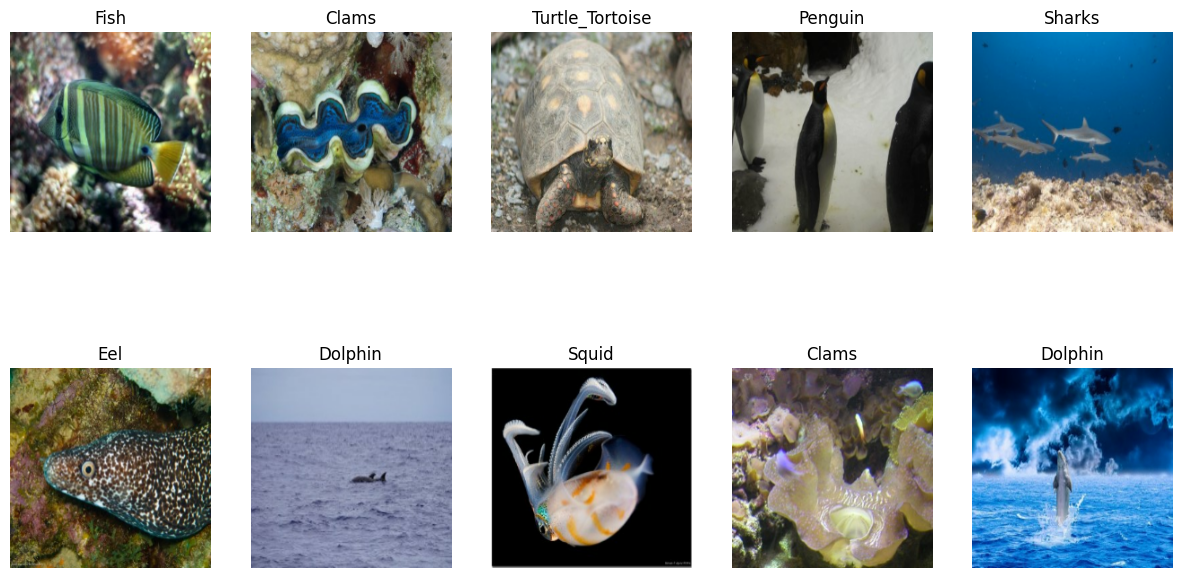

In [22]:
# Stampa a schermo i primi 10 elementi del dataset di training
images, labels = next(iter(train_ds))

class_names = train_ds.class_names

plt.figure(figsize=(15, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.show()

In [46]:
# Qui facciamo solo transfer learning (estraggo le feature ed addestro solo la porzione del classificatore)

# Questo script serve a trasformare l'input per adattarlo a quello di EfficientNet
train_ds_EN = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds_EN   = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds_EN  = test_ds.map(lambda x, y: (preprocess_input(x), y))

# Data Augumentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomFlip("vertical"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.15),
    tf.keras.layers.RandomBrightness(0.15),
])

# Include_top = false elimina la parte del classificatore
base_model = tf.keras.applications.EfficientNetB0(
    include_top = False,
    weights = "imagenet",
    input_shape = (224, 224, 3)
)

# Impedisco che il modello base possa essere ulteriormente addestrato (è congelato)
base_model.trainable = False

# Creo il nuovo classificatore e lo "aggancio alla rete"
inputs = tf.keras.Input(shape = (224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training = False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)

# Hidden layer con L2 regularization per ridurre overfitting
x = tf.keras.layers.Dense(
    256,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(num_classes, activation = "softmax")(x)

model = tf.keras.Model(inputs, outputs)

In [47]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping_phase1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Reduce LR on Plateau per ridurre il learning rate automaticamente
reduce_lr_phase1 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history_1 = model.fit(
    train_ds_EN,
    validation_data=val_ds_EN,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping_phase1, reduce_lr_phase1]
)

Epoch 1/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 67s 161ms/step - accuracy: 0.3977 - loss: 2.3519 - val_accuracy: 0.7609 - val_loss: 0.8552 - learning_rate: 0.0010
Epoch 2/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 52s 151ms/step - accuracy: 0.6104 - loss: 1.4115 - val_accuracy: 0.7827 - val_loss: 0.7792 - learning_rate: 0.0010
Epoch 3/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 83s 153ms/step - accuracy: 0.6604 - loss: 1.2595 - val_accuracy: 0.7958 - val_loss: 0.7703 - learning_rate: 0.0010
Epoch 4/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 51s 149ms/step - accuracy: 0.6665 - loss: 1.2061 - val_accuracy: 0.7914 - val_loss: 0.7404 - learning_rate: 0.0010
Epoch 5/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 51s 150ms/step - accuracy: 0.6810 - loss: 1.1622 - val_accuracy: 0.7958 - val_loss: 0.7649 - learning_rate: 0.0010
Epoch 6/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 52s 151ms/step - accuracy: 0.6871 - loss: 1.1513 - val_accuracy: 0.8052 - val_loss: 0.7408 - learning_rate: 0.0010
Epoch 7/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 52s 151ms/step - accuracy: 0.6

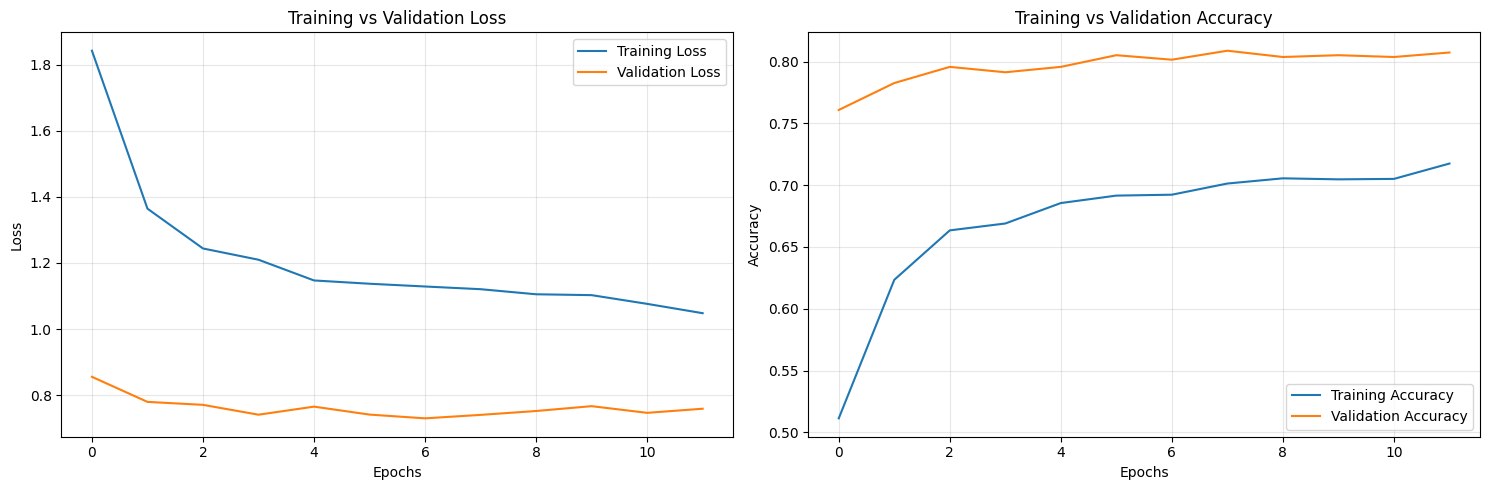

In [48]:
history_dict = history_1.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_dict['loss'], label='Training Loss')
ax1.plot(history_dict['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_dict['accuracy'], label='Training Accuracy')
ax2.plot(history_dict['val_accuracy'], label='Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
# Scongelo la prima porzione della rete
base_model.trainable = True

# Congelo tutti i layer tranne gli ultimi 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Continuo l'addestramento
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping_phase2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Reduce LR on Plateau per ridurre il learning rate automaticamente
reduce_lr_phase2 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

history_2 = model.fit(
    train_ds_EN,
    validation_data=val_ds_EN,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping_phase2, reduce_lr_phase2]
)

Epoch 1/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 71s 166ms/step - accuracy: 0.7676 - loss: 0.8830 - val_accuracy: 0.8249 - val_loss: 0.6937 - learning_rate: 5.0000e-05
Epoch 2/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 53s 156ms/step - accuracy: 0.7752 - loss: 0.8580 - val_accuracy: 0.8241 - val_loss: 0.6892 - learning_rate: 5.0000e-05
Epoch 3/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 54s 157ms/step - accuracy: 0.7783 - loss: 0.8330 - val_accuracy: 0.8350 - val_loss: 0.6754 - learning_rate: 5.0000e-05
Epoch 4/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 55s 160ms/step - accuracy: 0.7857 - loss: 0.8295 - val_accuracy: 0.8379 - val_loss: 0.6625 - learning_rate: 5.0000e-05
Epoch 5/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 54s 157ms/step - accuracy: 0.7834 - loss: 0.8091 - val_accuracy: 0.8314 - val_loss: 0.6798 - learning_rate: 5.0000e-05
Epoch 6/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 53s 156ms/step - accuracy: 0.7843 - loss: 0.8043 - val_accuracy: 0.8365 - val_loss: 0.6794 - learning_rate: 5.0000e-05
Epoch 7/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 54s 15

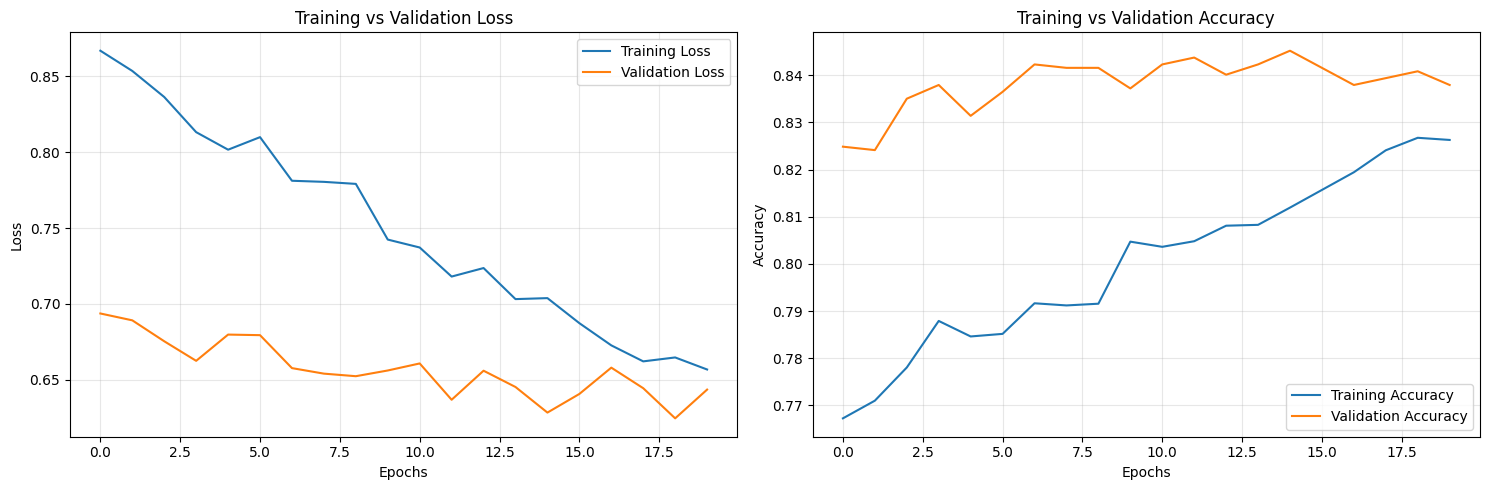

In [52]:
history_dict = history_2.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_dict['loss'], label='Training Loss')
ax1.plot(history_dict['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_dict['accuracy'], label='Training Accuracy')
ax2.plot(history_dict['val_accuracy'], label='Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()